<a href="https://colab.research.google.com/github/SahputraS/Flu-Forecast/blob/main/VAR_EVAL_PLOT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Patch

import numpy as np
import math

import seaborn as sns

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
data_ili = pd.read_csv('/content/drive/MyDrive/Flu Forecast/latest-forecast_scores_ili.csv')
data_ili = data_ili[data_ili['target'] == 'ILI incidence']

In [ ]:
data_ari = pd.read_csv('/content/drive/MyDrive/Flu Forecast/latest-forecast_scores_ari.csv')
data_ari = data_ari[data_ari['target'] == 'ARI incidence']

In [ ]:
data_all = pd.concat([data_ili, data_ari], axis=0)
data_all = data_all[data_all['model_id'] != 'RespiVAR-old']
data_all = data_all[data_all['model_id'] != 'RespiVAR']
data_all.loc[data_all['model_id'] == 'RespiVAR-0sfixed', 'model_id'] = 'RespiVAR'

In [ ]:
data_all2 = pd.read_csv('latest-forecast_scores.csv')

In [ ]:
exclude_locations = ['GB-ENG', 'GB-NIR', 'GB-SCT', 'GB-WLS', 'CH']

data_all3 = data_all[
    (data_all['origin_date'] >= data_all2['origin_date'].min()) &
    (data_all['target_end_date'] <= data_all2['target_end_date'].max()) &
    (data_all['model_id'] != 'RespiVAR') &
    (~data_all['location'].isin(exclude_locations))
].drop(columns=['baseline_value']).reset_index(drop=True)

In [ ]:
data_all2

,origin_date,target,target_end_date,horizon,location,team_id,model_id,metric,value_absolute,value_relative,n_models,rank,rank_score
0,2024-10-23,ILI incidence,2024-10-20,1,AT,ECDC,SARIMA,WIS,328.856452,-0.143958,10,3,0.882153
1,2024-10-23,ILI incidence,2024-10-20,1,AT,ItaLuxColab,EpiEKF,WIS,164.338422,0.856830,10,1,1.000000
2,2024-10-23,ILI incidence,2024-10-20,1,AT,ItaLuxColab,EpiNetEKF,WIS,376.027352,-0.337338,10,5,0.848364
3,2024-10-23,ILI incidence,2024-10-20,1,AT,MRC_GIDA,CATBoost,WIS,545.332289,-0.873636,10,7,0.727089
4,2024-10-23,ILI incidence,2024-10-20,1,AT,MRC_GIDA,NBEATS,WIS,1560.374800,-2.390321,10,10,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
203252,2026-03-04,ARI incidence,2026-03-01,1,SK,ISI,LSTFlu,AE,183.381272,-0.306328,10,9,0.731486
203253,2026-03-04,ARI incidence,2026-03-01,1,SK,NotreDame,Rt_cocirc,AE,116.500000,0.348189,10,7,0.844781
203254,2026-03-04,ARI incidence,2026-03-01,1,SK,respicast,hubEnsemble,AE,68.690057,1.110345,10,3,0.925769
203255,2026-03-04,ARI incidence,2026-03-01,1,SK,respicast,quantileBaseline,AE,148.300000,0.000000,10,8,0.790913


In [ ]:
data_all3

,origin_date,target,target_end_date,horizon,location,team_id,model_id,metric,value_absolute,value_relative,n_models,rank,rank_score
0,2024-10-23,ILI incidence,2024-10-20,1,AT,ECDC,SARIMA,WIS,328.856452,-0.143958,10,3,0.882153
1,2024-10-23,ILI incidence,2024-10-20,1,AT,ItaLuxColab,EpiEKF,WIS,164.338422,0.856830,10,1,1.000000
2,2024-10-23,ILI incidence,2024-10-20,1,AT,ItaLuxColab,EpiNetEKF,WIS,376.027352,-0.337338,10,5,0.848364
3,2024-10-23,ILI incidence,2024-10-20,1,AT,MRC_GIDA,CATBoost,WIS,545.332289,-0.873636,10,7,0.727089
4,2024-10-23,ILI incidence,2024-10-20,1,AT,MRC_GIDA,NBEATS,WIS,1560.374800,-2.390321,10,10,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
156805,2025-12-10,ARI incidence,2025-12-07,1,SI,MRC_GIDA,TiDE,AE,1278.420048,-0.916495,15,12,0.227853
156806,2025-12-10,ARI incidence,2025-12-07,1,SI,NotreDame,Rt_cocirc,AE,1139.300000,-0.750281,15,11,0.329569
156807,2025-12-10,ARI incidence,2025-12-07,1,SI,respicast,hubEnsemble,AE,730.696799,-0.109478,15,7,0.628315
156808,2025-12-10,ARI incidence,2025-12-07,1,SI,respicast,quantileBaseline,AE,677.300000,0.000000,15,6,0.667356


In [ ]:
keys = ['origin_date', 'target', 'target_end_date', 'horizon', 'location', 'team_id', 'model_id', 'metric']

merged = data_all2.merge(data_all3, on=keys, suffixes=('_2', '_3'))

merged['value_absolute_match'] = np.isclose(merged['value_absolute_2'], merged['value_absolute_3'])
merged['value_relative_match'] = np.isclose(merged['value_relative_2'], merged['value_relative_3'])
merged['all_match'] = merged['value_absolute_match'] & merged['value_relative_match']

print(f"Rows in common: {len(merged)}")
print(f"All match: {merged['all_match'].sum()} / {len(merged)}")
print(f"\nMismatches:")
print(f"  value_absolute: {(~merged['value_absolute_match']).sum()}")
print(f"  value_relative: {(~merged['value_relative_match']).sum()}")

mismatches = merged[~merged['all_match']]
mismatches[keys + ['value_absolute_2', 'value_absolute_3', 'value_relative_2', 'value_relative_3']]

Rows in common: 152938
All match: 141354 / 152938

Mismatches:
  value_absolute: 11584
  value_relative: 10503


,origin_date,target,target_end_date,horizon,location,team_id,model_id,metric,value_absolute_2,value_absolute_3,value_relative_2,value_relative_3
10,2024-10-23,ILI incidence,2024-10-20,1,BE,ECDC,SARIMA,WIS,40.988401,42.859046,0.297496,0.297284
11,2024-10-23,ILI incidence,2024-10-20,1,BE,ECDC,soca_simplex,WIS,143.019991,145.850425,-1.505433,-1.469534
12,2024-10-23,ILI incidence,2024-10-20,1,BE,ISI,FluABCaster,WIS,95.684541,98.784541,-0.925574,-0.907401
13,2024-10-23,ILI incidence,2024-10-20,1,BE,ISI,FluBcast,WIS,68.906358,72.006358,-0.451925,-0.451241
14,2024-10-23,ILI incidence,2024-10-20,1,BE,ISI,RC_AdaptEns2,WIS,90.860550,93.960550,-0.850942,-0.835171
...,...,...,...,...,...,...,...,...,...,...,...,...
152887,2025-12-10,ARI incidence,2025-12-07,1,IT,ISI,FluABCaster,AE,126.212912,36.312912,1.122522,2.348191
152888,2025-12-10,ARI incidence,2025-12-07,1,IT,ISI,GLEAM,AE,179.320000,89.420000,0.615846,1.048076
152889,2025-12-10,ARI incidence,2025-12-07,1,IT,ISI,LSTFlu,AE,180.893907,90.993907,0.603238,1.022903
152890,2025-12-10,ARI incidence,2025-12-07,1,IT,respicast,hubEnsemble,AE,152.766456,62.866456,0.847054,1.556383


##  WIS and AE Relative score (Pairwise Comparison)

Manual

In [21]:
def pairwise_eval(data_all, met, tgt, h=None):
  df_metric = data_all[(data_all["metric"] == met) & (data_all["target"] == tgt)].copy()

  if h is not None:
    df_metric = df_metric[df_metric["horizon"] == h].copy()

  models = df_metric[["team_id", "model_id"]].drop_duplicates().reset_index(drop=True)
  keys = ["origin_date", "target_end_date", "horizon", "location"]

  # Pivot to wide format: rows = forecast conditions, cols = models
  df_pivot = df_metric.pivot_table(
      index=keys,
      columns=["team_id", "model_id"],
      values="value_absolute"
  )

  model_cols = df_pivot.columns

  n = len(model_cols)
  theta_matrix = np.full((n, n), np.nan)

  for i in range(n):
      for j in range(n):
          if i == j: #if to self, then don't do
              continue
          shared = df_pivot.iloc[:, i].notna() & df_pivot.iloc[:, j].notna()
          if shared.sum() == 0:
              continue
          avg_i = df_pivot.iloc[:, i][shared].mean()
          avg_j = df_pivot.iloc[:, j][shared].mean()
          theta_matrix[i, j] = avg_i / avg_j

  # Geometric mean per model (ignoring NaN pairs)
  log_theta = np.log(theta_matrix)
  theta_m = np.exp(np.nanmean(log_theta, axis=1))

  # Normalize by baseline
  baseline_idx = model_cols.tolist().index(("respicast", "quantileBaseline"))
  theta_star = theta_m / theta_m[baseline_idx]

  # Build result dataframe
  df_result = pd.DataFrame({
      "team_id": [c[0] for c in model_cols],
      "model_id": [c[1] for c in model_cols],
      "theta_m": theta_m,
      "theta_star": theta_star
  }).sort_values("theta_star").reset_index(drop=True)

  # Theta matrix
  labels = [f"{c[0]}-{c[1]}" for c in model_cols]
  df_theta_matrix = pd.DataFrame(
      theta_matrix,
      index=labels,
      columns=labels
  )

  return(df_result, df_theta_matrix)

In [25]:
## ALl countries
met = "WIS"
tgt = "ILI incidence"
h = None
data_past = data_all2[data_all2['target_end_date'] <= '2025-03-23']

WIS_pe, t_mat = pairwise_eval(data_past, met, tgt, h=h)

diagnostic

In [41]:
kfd = data_all2[(data_all2['model_id']=='KFdlm') & (data_all2['metric'] == 'WIS')]
kfd.head(5)

,origin_date,target,target_end_date,horizon,location,team_id,model_id,metric,value_absolute,value_relative,n_models,rank,rank_score
1849,2024-11-06,ILI incidence,2024-11-03,1,AT,NotreDame,Rt_cocirc,WIS,2443.122913,-1.439661,5,5,0.000000
1857,2024-11-06,ILI incidence,2024-11-03,1,BE,NotreDame,Rt_cocirc,WIS,192.687520,-0.905963,13,12,0.410283
1876,2024-11-06,ILI incidence,2024-11-03,1,CZ,NotreDame,Rt_cocirc,WIS,14.385850,-1.933035,7,6,0.126916
1883,2024-11-06,ILI incidence,2024-11-03,1,DK,NotreDame,Rt_cocirc,WIS,44.496689,-1.852594,7,7,0.000000
1892,2024-11-06,ILI incidence,2024-11-03,1,EE,NotreDame,Rt_cocirc,WIS,145.277059,-2.139075,9,9,0.000000


In [47]:
kfd['value_absolute'].min()

0.0

In [48]:
kfd['value_absolute'].max()

2.32278964597193e+30

In [69]:
weird = data_all2[(data_all2['target'] == 'ILI incidence')& (data_all2['metric'] == 'WIS') & (data_all2['metric'] == 'WIS') & (data_all2['value_absolute'] > 1e+5)]
weird['model_id'].unique()

array(['KFdlm', 'Rt_cocirc'], dtype=object)

In [75]:
weird[weird['model_id']=='KFdlm']['location'].unique()

array(['LU', 'AT'], dtype=object)

In [77]:
weird[(weird['model_id']=='KFdlm') & (weird['location']=='AT')]

,origin_date,target,target_end_date,horizon,location,team_id,model_id,metric,value_absolute,value_relative,n_models,rank,rank_score,order
19394,2025-02-12,ILI incidence,2025-02-09,1,AT,RIVM,KFdlm,WIS,9.432278e+07,-18.476627,16,16,0.0,7.0
19771,2025-02-12,ILI incidence,2025-02-16,2,AT,RIVM,KFdlm,WIS,4.453788e+08,-21.182422,16,16,0.0,8.0
20148,2025-02-12,ILI incidence,2025-02-23,3,AT,RIVM,KFdlm,WIS,3.488441e+43,-136.496313,16,16,0.0,43.0
20515,2025-02-12,ILI incidence,2025-03-02,4,AT,RIVM,KFdlm,WIS,9.037507e+84,-273.998253,16,16,0.0,84.0


In [85]:
kf_lu = weird[(weird['model_id']=='KFdlm') & (weird['location']=='LU')]
kf_lu

,origin_date,target,target_end_date,horizon,location,team_id,model_id,metric,value_absolute,value_relative,n_models,rank,rank_score,order
805,2024-10-23,ILI incidence,2024-11-03,3,LU,RIVM,KFdlm,WIS,2.677875e+05,-8.016951,14,14,0.0,5.0
1104,2024-10-23,ILI incidence,2024-11-10,4,LU,RIVM,KFdlm,WIS,2.190418e+06,-10.739573,14,14,0.0,6.0
1644,2024-10-30,ILI incidence,2024-11-10,3,LU,RIVM,KFdlm,WIS,1.788429e+06,-11.164460,7,7,0.0,6.0
1788,2024-10-30,ILI incidence,2024-11-17,4,LU,RIVM,KFdlm,WIS,1.770154e+06,-10.581061,7,7,0.0,6.0
2179,2024-11-06,ILI incidence,2024-11-10,2,LU,RIVM,KFdlm,WIS,1.788429e+06,-11.160520,8,8,0.0,6.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
66866,2026-02-11,ILI incidence,2026-02-15,2,LU,RIVM,KFdlm,WIS,1.305532e+05,-6.503057,20,20,0.0,5.0
67238,2026-02-11,ILI incidence,2026-02-22,3,LU,RIVM,KFdlm,WIS,3.810441e+05,-8.251786,20,20,0.0,5.0
67624,2026-02-11,ILI incidence,2026-03-01,4,LU,RIVM,KFdlm,WIS,3.277620e+06,-9.799887,20,20,0.0,6.0
68321,2026-02-18,ILI incidence,2026-02-22,2,LU,RIVM,KFdlm,WIS,1.269583e+05,-6.793294,15,15,0.0,5.0


In [83]:
kf_lu['order'] = np.where(
    kf_lu['value_absolute'] > 0,
    np.floor(np.log10(kf_lu['value_absolute'].abs())),
    np.nan)

kf_lu['order'].value_counts().sort_index()

/tmp/ipykernel_2040/4044786478.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  kf_lu['order'] = np.where(


,count
order,
5.0,47
6.0,51
7.0,4


In [73]:
weird[weird['model_id']=='Rt_cocirc']

,origin_date,target,target_end_date,horizon,location,team_id,model_id,metric,value_absolute,value_relative,n_models,rank,rank_score,order
37415,2025-06-25,ILI incidence,2025-06-22,1,CZ,NotreDame,Rt_cocirc,WIS,2.842840e+08,-27.637584,10,10,0.0,8.0
37576,2025-06-25,ILI incidence,2025-06-29,2,CZ,NotreDame,Rt_cocirc,WIS,5.725977e+15,-50.988218,10,10,0.0,15.0
37737,2025-06-25,ILI incidence,2025-07-06,3,CZ,NotreDame,Rt_cocirc,WIS,1.153267e+23,-74.798797,10,10,0.0,23.0
37897,2025-06-25,ILI incidence,2025-07-13,4,CZ,NotreDame,Rt_cocirc,WIS,2.322790e+30,-98.752330,10,10,0.0,30.0


In [70]:
data_all2['order'] = np.where(
    data_all2['value_absolute'] > 0,
    np.floor(np.log10(data_all2['value_absolute'].abs())),
    np.nan)

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [71]:
data_all2['order'].value_counts().sort_index()

,count
order,
-17.0,2
-16.0,5
-15.0,5
-14.0,2
-11.0,4
-6.0,2
-5.0,5
-4.0,76
-3.0,232


In [ ]:
def pairwise_eval_by_location(data_all, met, tgt, h=None):
    locations = data_all["location"].unique()

    results = {}
    for loc in locations:
        try:
            df_result, t_mat = pairwise_eval(data_all[data_all["location"] == loc], met, tgt, h=h)
            results[loc] = df_result
        except Exception as e:
            print(f"Skipped {loc}: {e}")

    df_combined = pd.concat(
        [df.assign(location=loc) for loc, df in results.items()],
        ignore_index=True
    )
    return df_combined

In [ ]:
# Per countries
met = "WIS"
tgt = "ILI incidence"
h = None
data_past = data_all[data_all['target_end_date'] <= '2025-04-06']

df_pc = pairwise_eval_by_location(data_past, met, tgt, h=h)

Skipped BG: ('respicast', 'quantileBaseline') is not in list
Skipped DE: ('respicast', 'quantileBaseline') is not in list
Skipped ES: ('respicast', 'quantileBaseline') is not in list
Skipped CY: ('respicast', 'quantileBaseline') is not in list


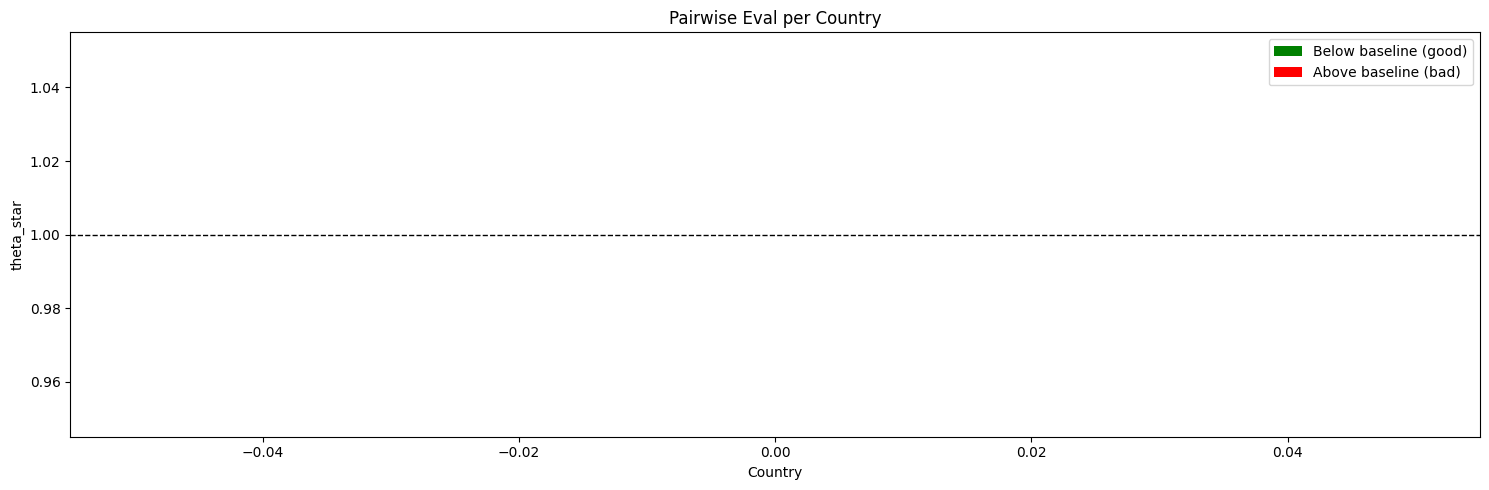

In [ ]:
pc_rv = df_pc[df_pc['model_id']=='SEIR-BWR'].sort_values("theta_star")

fig, ax = plt.subplots(figsize=(15, 5))

colors = ["green" if v < 1 else "red" for v in pc_rv["theta_star"]]
bars = ax.bar(pc_rv["location"], pc_rv["theta_star"], color=colors, edgecolor="white")

ax.axhline(y=1, color="black", linestyle="--", linewidth=1)

# Value label
for bar, val in zip(bars, pc_rv["theta_star"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f"{val:.2f}", ha="center", va="bottom", fontsize=9)

ax.set_xlabel("Country")
ax.set_ylabel("theta_star")
ax.set_title("Pairwise Eval per Country")

ax.legend(handles=[Patch(facecolor="green", label="Below baseline (good)"),
                   Patch(facecolor="red", label="Above baseline (bad)")])

plt.tight_layout()
plt.show()

In [23]:
def plot_theta_star(df_pe, met, tgt, h, ax=None, x_cap_percentile=90, x_cap_max=5.0):
    df = df_pe.sort_values("theta_star", ascending=True).copy()
    labels = df["team_id"] + "\n" + df["model_id"]
    values = df["theta_star"].values
    n = len(df)

    colors = ["#27ae60" if v < 1.0 else "#e74c3c" for v in values]
    colors = ["#95a5a6" if (row.team_id == "respicast" and row.model_id == "quantileBaseline")
              else colors[i]
              for i, (_, row) in enumerate(df.iterrows())]

    if ax is None:
        fig, ax = plt.subplots(figsize=(10, max(6, n * 0.4)))

    ax.set_facecolor("white")

    # Compute x cap
    x_cap = min(np.nanpercentile(values, x_cap_percentile) * 1.5, x_cap_max)
    x_cap = max(x_cap, 1.5)
    display_values = np.clip(values, 0, x_cap)

    bars = ax.barh(range(n), display_values, color=colors, height=0.6, zorder=3)
    ax.axvline(x=1.0, color="black", linewidth=1.2, linestyle="--", alpha=0.6, zorder=4)

    for idx, (v, dv) in enumerate(zip(values, display_values)):
        if v > x_cap:
            ax.text(x_cap * 0.97, idx, f"▶ {v:.2e}", va="center", ha="right",
                    fontsize=9, color="white", fontweight="bold")
        else:
            x_pos = dv + x_cap * 0.01
            ax.text(x_pos, idx, f"{v:.2f}", va="center", ha="left",
                    fontsize=9, color="black")

    ax.set_xlim(0, x_cap * 1.15)
    ax.set_yticks(range(n))

    # Y tick labels — bold red for RespiVAR
    yticklabels = ax.set_yticklabels(labels, fontsize=10, color="black")
    for i, (ticklabel, (_, row)) in enumerate(zip(yticklabels, df.iterrows())):
        if row["model_id"] == "RespiVAR":
            ticklabel.set_color("#c0392b")
            ticklabel.set_fontweight("bold")

    ax.set_xlabel("θ*  (< 1 = better than baseline)", fontsize=11, color="black")
    ax.set_title(f"{met}  |  {tgt}  |  h={h}", fontsize=12,
                 color="black", fontweight="bold", pad=12)
    ax.tick_params(axis="x", colors="black", labelsize=10)
    ax.tick_params(axis="y", colors="black", labelsize=10)
    ax.spines[["top", "right", "left"]].set_visible(False)
    ax.spines["bottom"].set_color("#cccccc")
    ax.xaxis.grid(True, color="#eeeeee", linewidth=0.5, zorder=0)
    ax.set_axisbelow(True)

    return ax

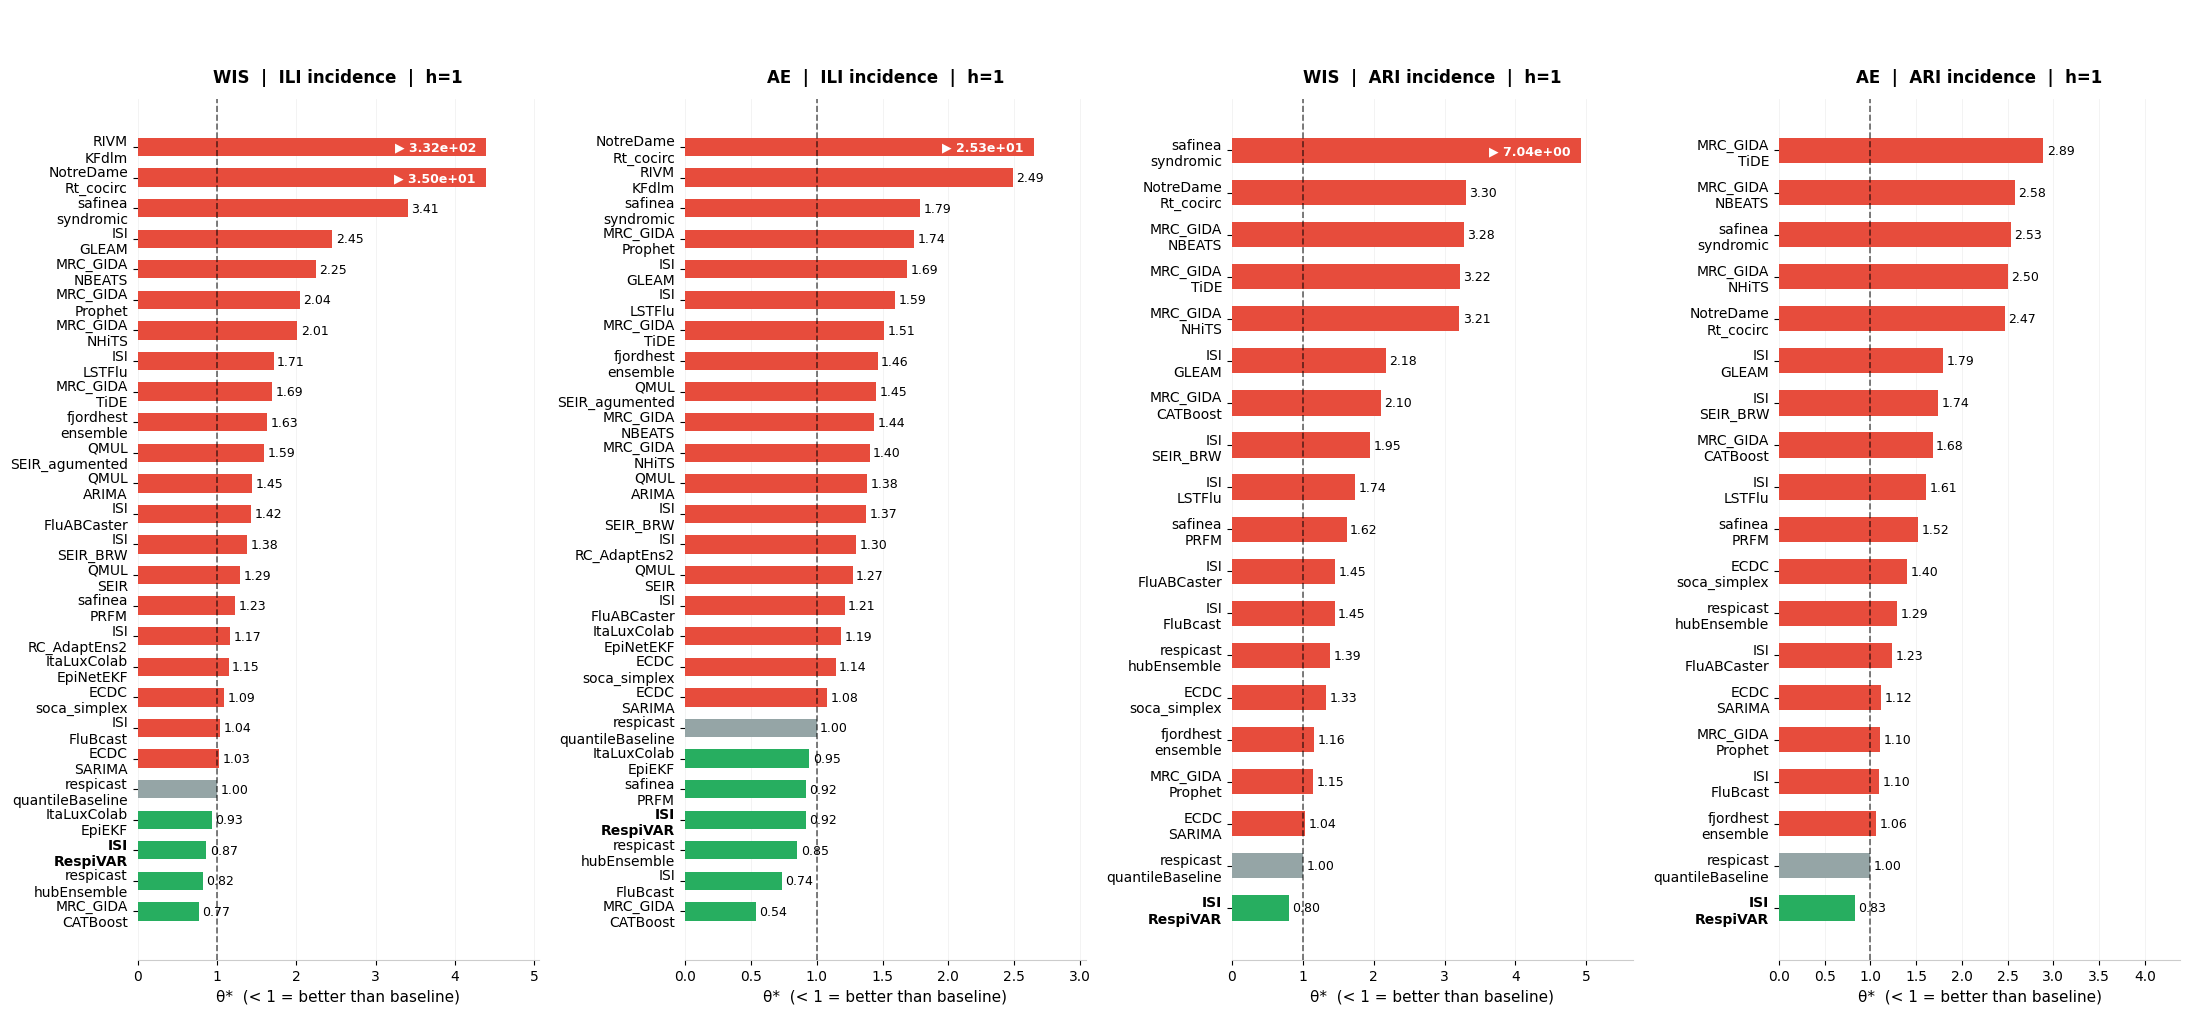

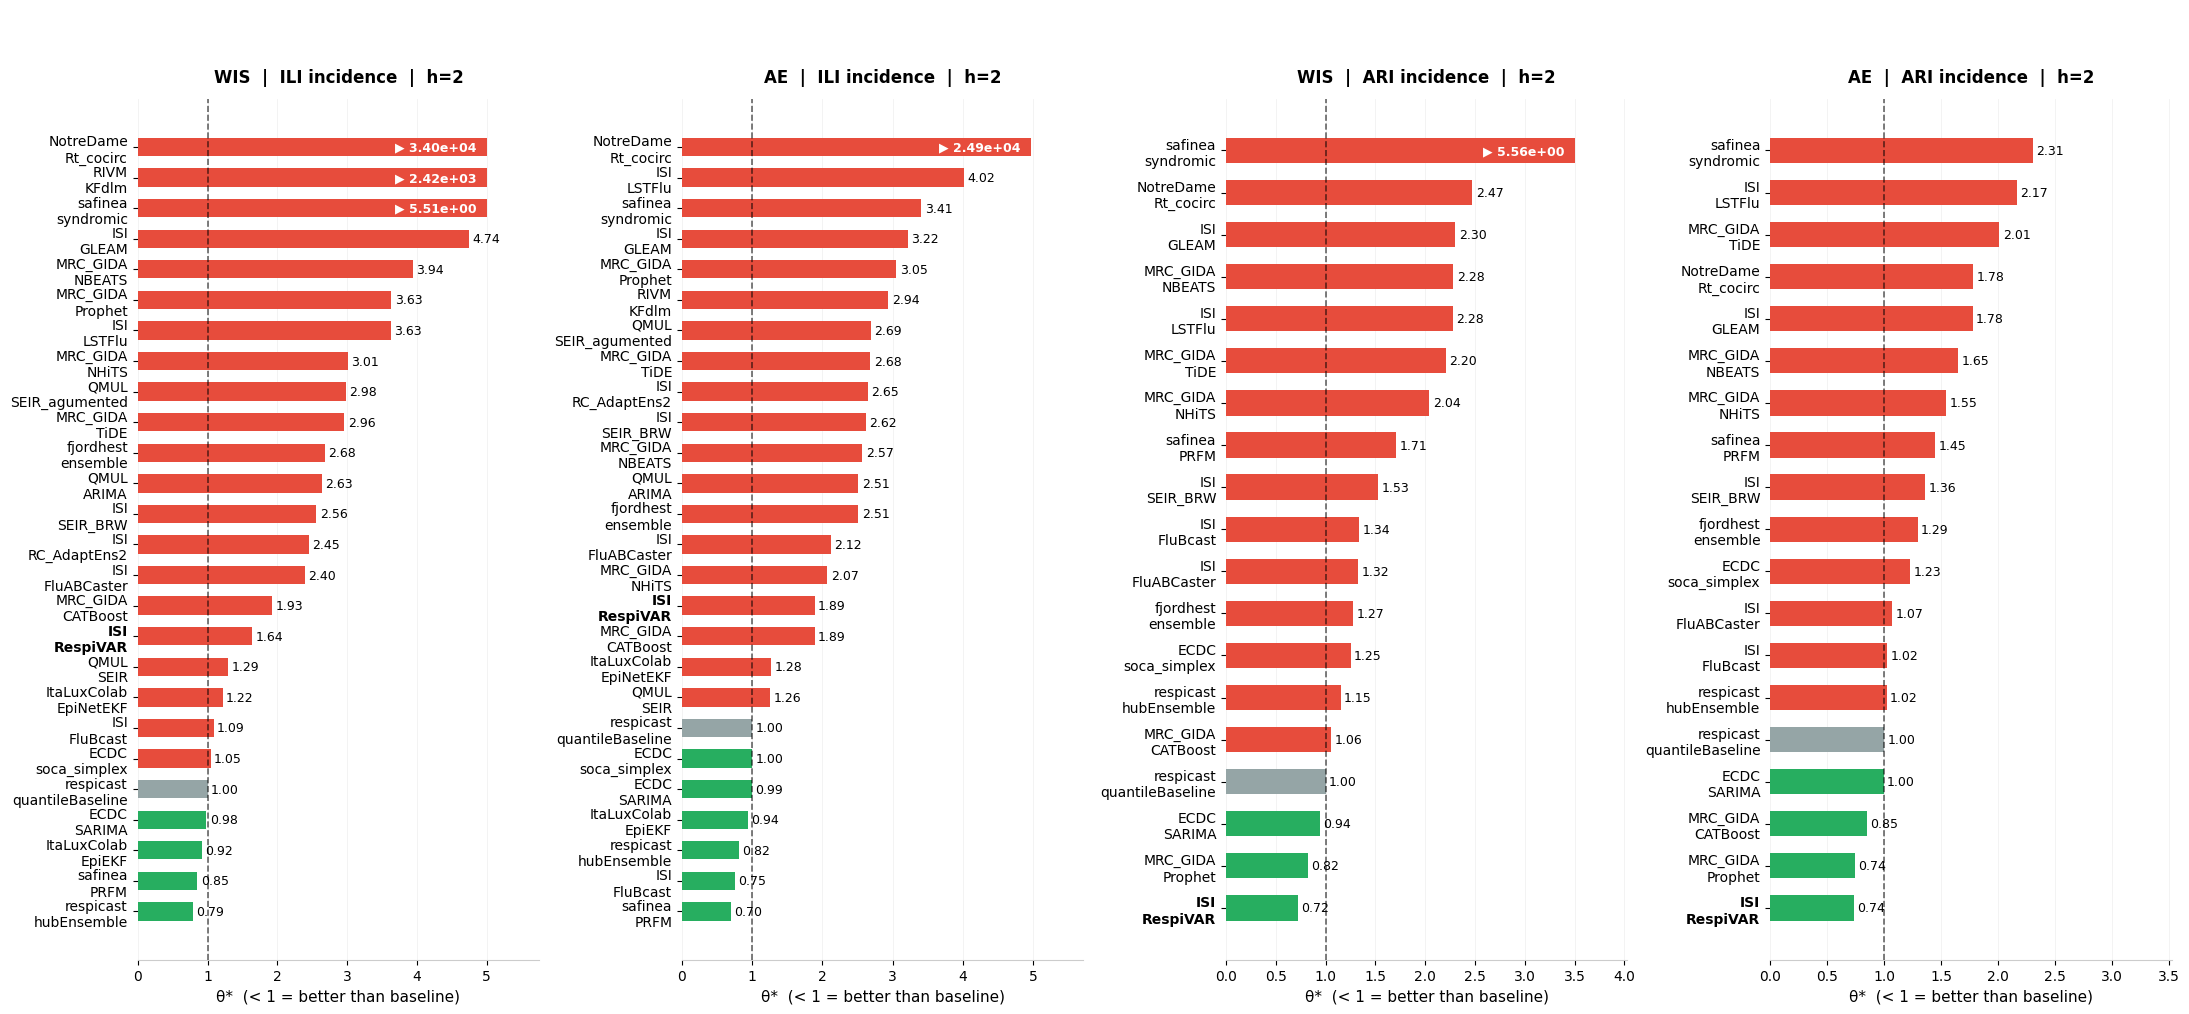

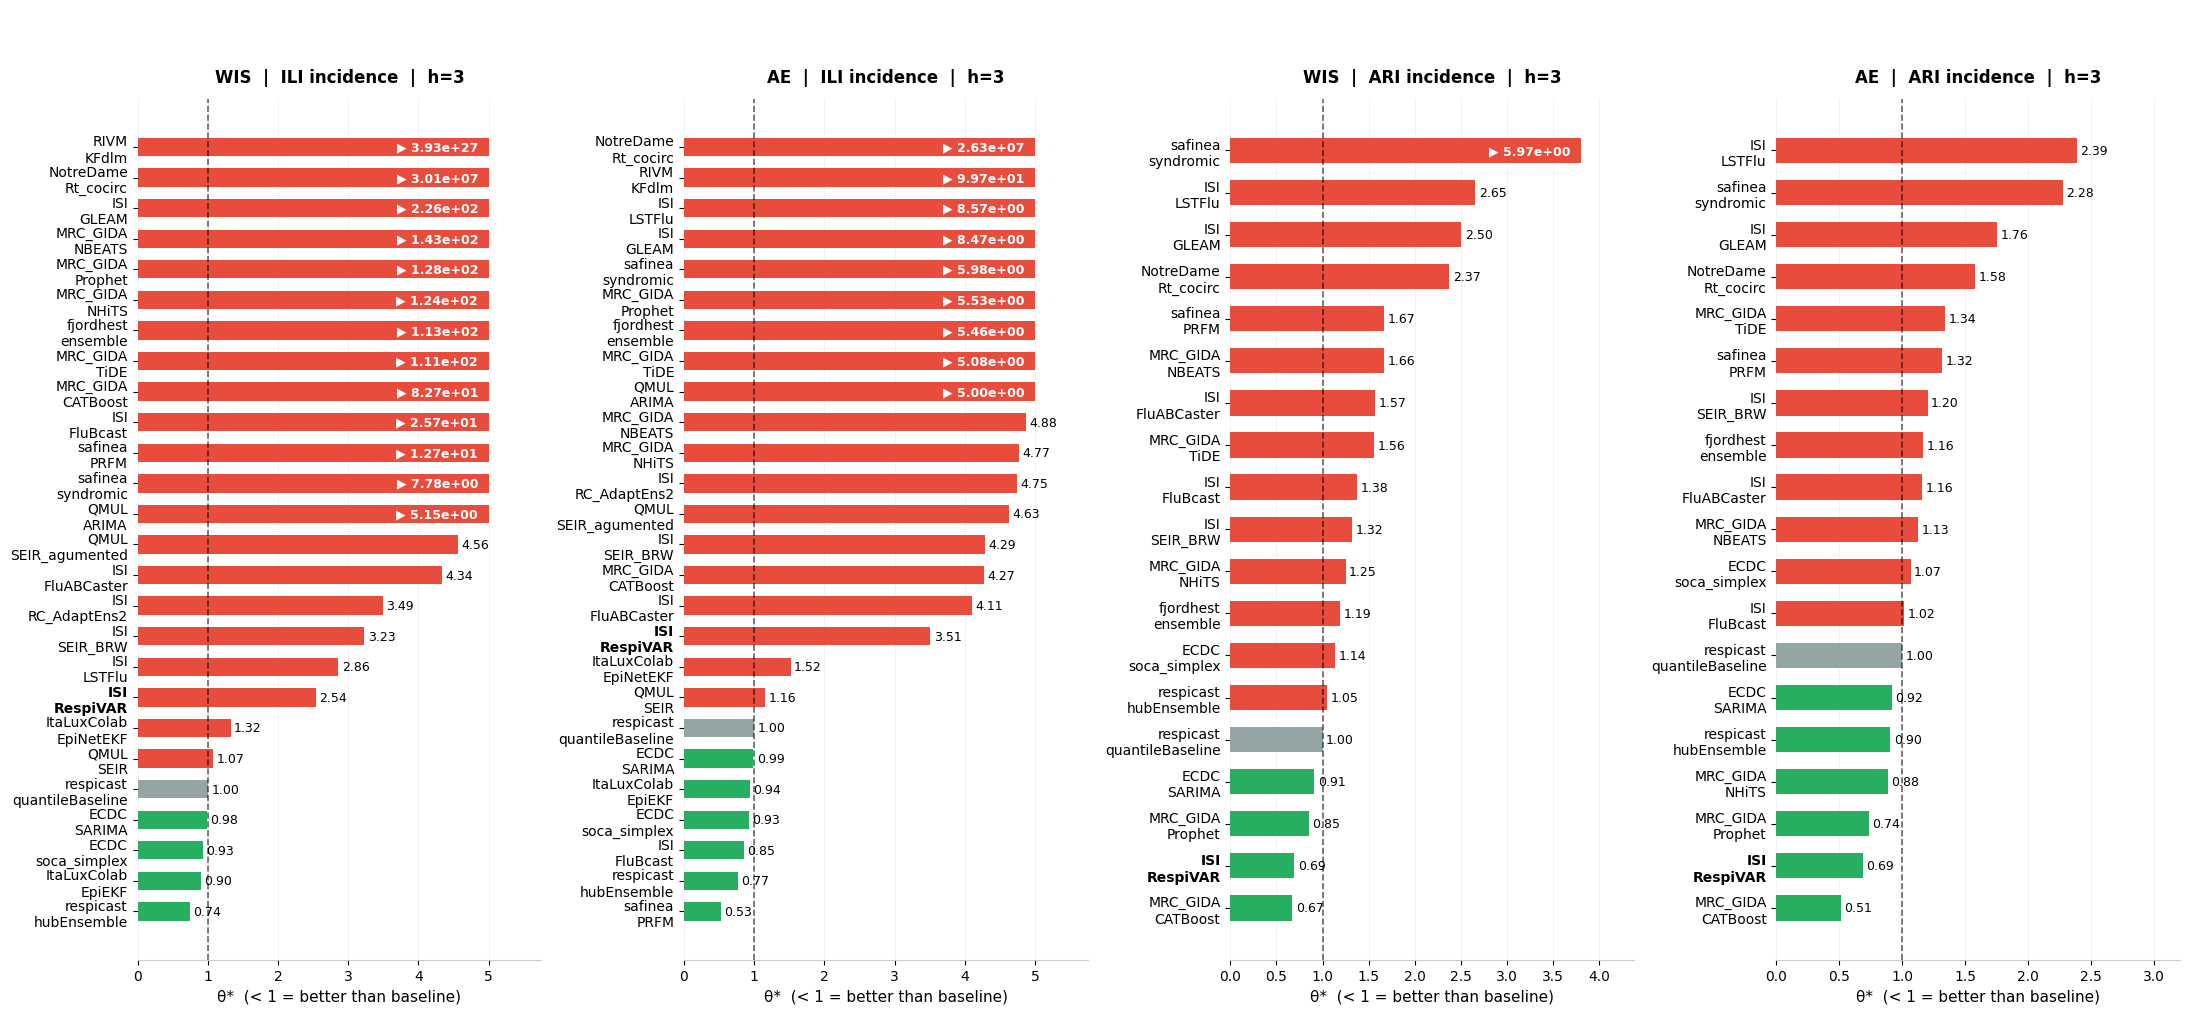

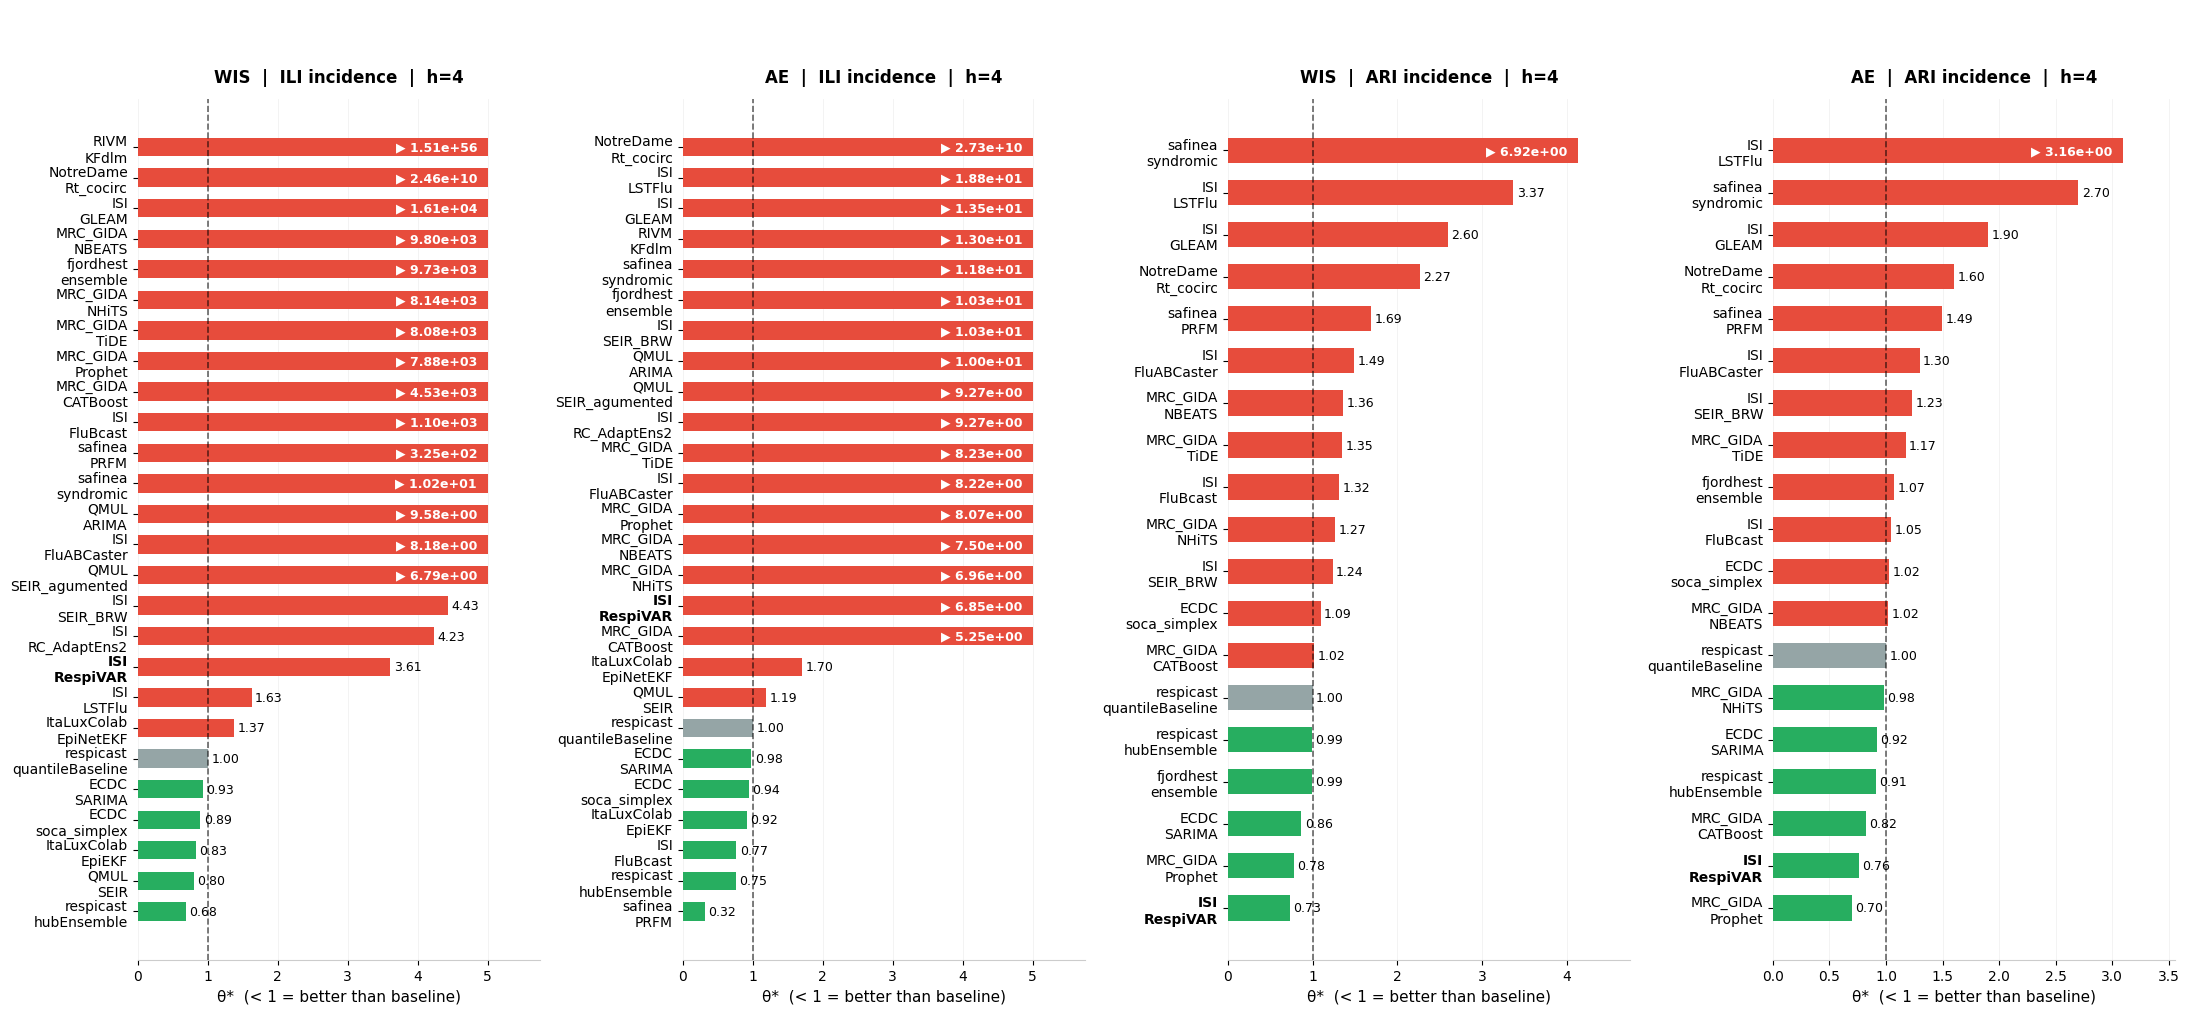

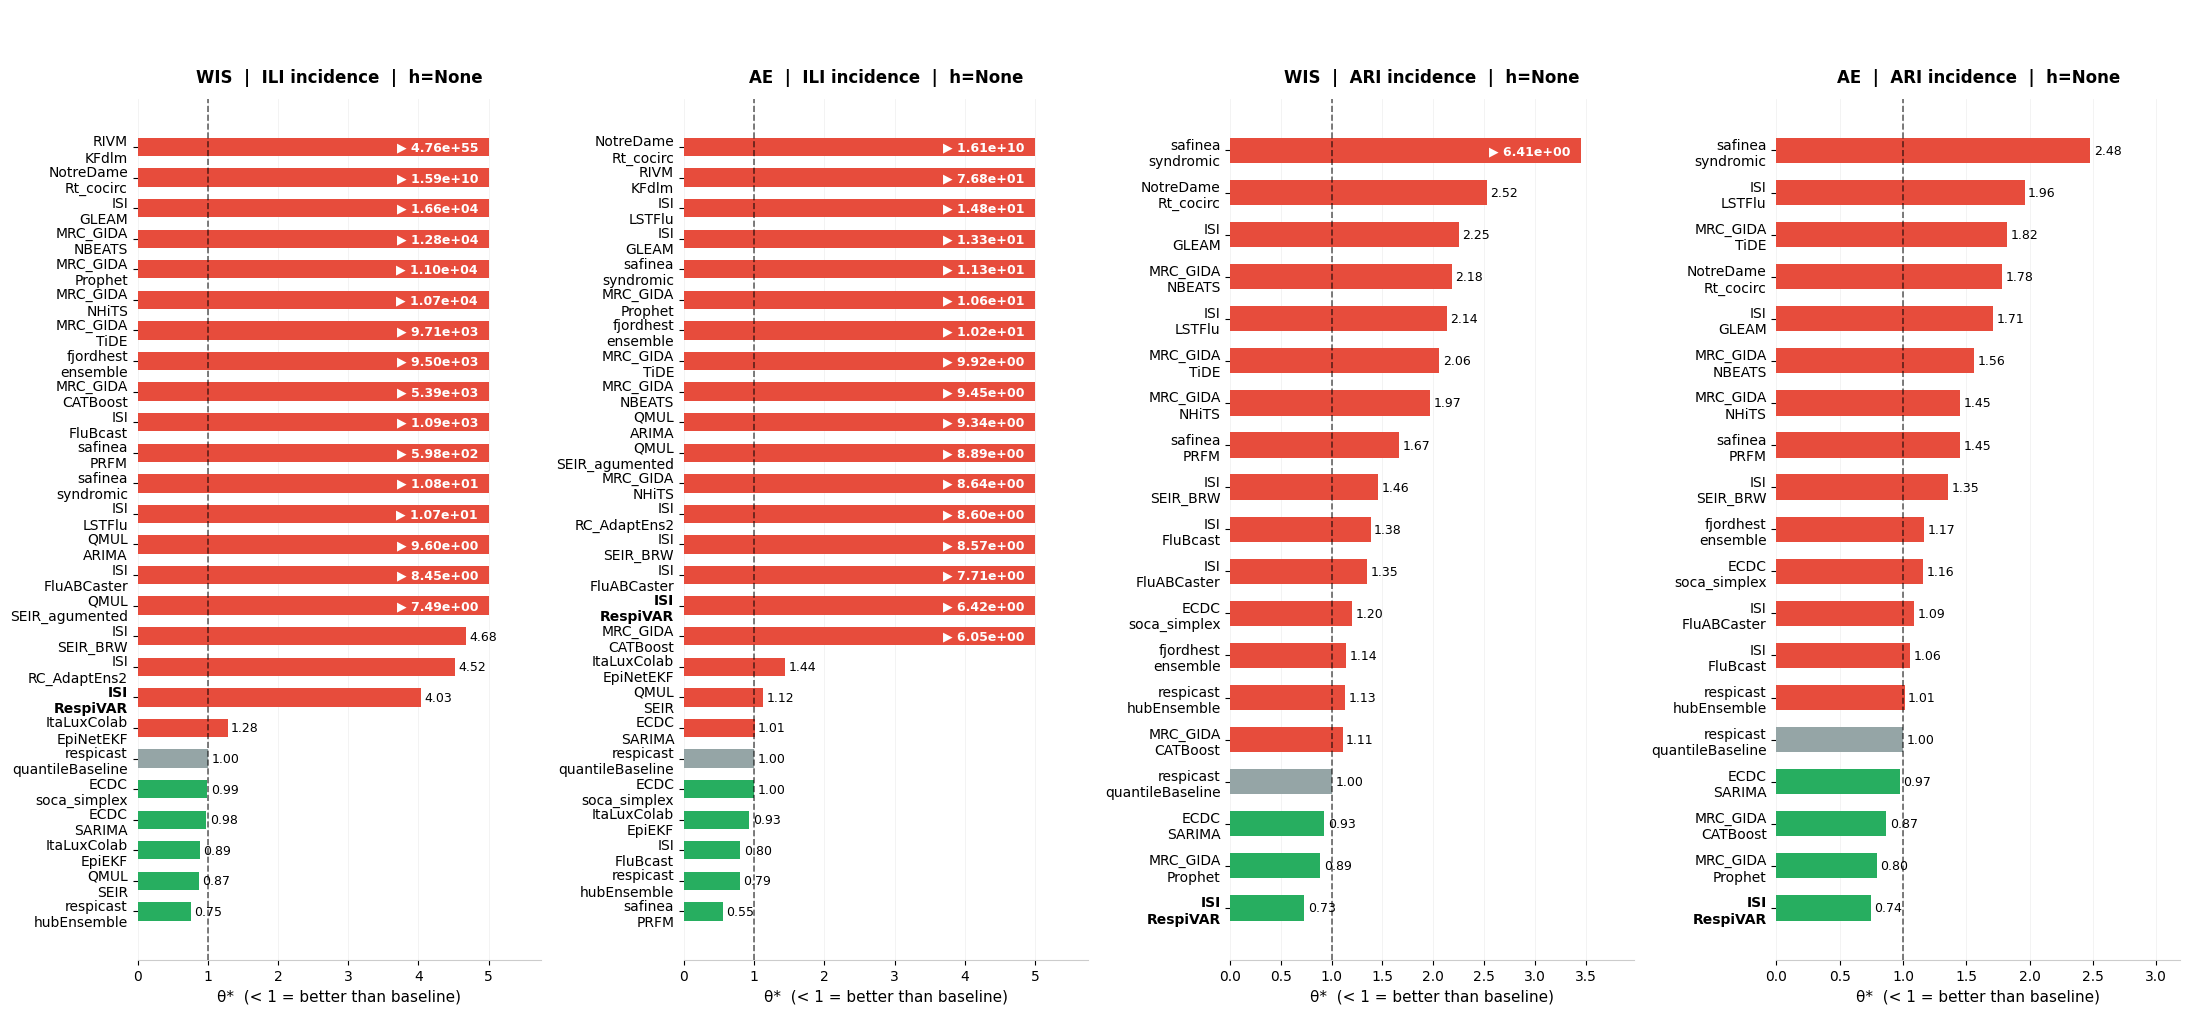

In [24]:
metrics = ["WIS", "AE"]
targets = ["ILI incidence", "ARI incidence"]
horizons = [1, 2, 3, 4, None]

for h in horizons:
    fig, axes = plt.subplots(1, len(metrics) * len(targets),
                             figsize=(22, 10))
    fig.suptitle(f"Relative Forecast Performance  —  Horizon {h}",
                 fontsize=14, color="white", fontweight="bold", y=1.01)

    idx = 0
    for tgt in targets:
        for met in metrics:
            ax = axes[idx]
            try:
                df_pe, _ = pairwise_eval(data_all, met, tgt, h=h)
                plot_theta_star(df_pe, met, tgt, h, ax=ax)
            except Exception as e:
                ax.text(0.5, 0.5, f"No data\n{e}", ha="center", va="center",
                        color="white", fontsize=8, transform=ax.transAxes)
                ax.set_title(f"{met} | {tgt} | h={h}", color="white", fontsize=9)
            idx += 1

    plt.tight_layout()
    plt.show()

## Respicast style eval

In [ ]:
# cutoff = pd.Timestamp("2025-05-01")

# respivar_h4 = data_all[
#     (data_all["model_id"] == "RespiVAR") &
#     (data_all["horizon"] == 4)
# ].copy()

# respivar_h4["target_end_date"] = pd.to_datetime(respivar_h4["target_end_date"])
# respivar_h4["origin_date"] = pd.to_datetime(respivar_h4["origin_date"])

# max_end_pre_may = respivar_h4.loc[respivar_h4["target_end_date"] < cutoff, "target_end_date"].max()
# print("Max respivar h=4 target_end_date:", max_end_pre_may.date())

# # 1) origin_date(s) that generated that max target_end_date
# od_at_max = (
#     respivar_h4.loc[respivar_h4["target_end_date"] == max_end_pre_may, "origin_date"]
#     .drop_duplicates()
#     .sort_values()
# )
# print("respivar origin_date(s) for that max target_end_date:")
# print(od_at_max.dt.date.tolist())

# # usually it should be one date; take the latest if multiple
# last_origin = od_at_max.max()
# print("Using last_origin =", last_origin.date())

# # 2) all respivar origin_dates from the beginning up to last_origin (across all horizons/targets)
# respivar_all = data_all[data_all["model_id"] == "RespiVAR"].copy()
# respivar_all["origin_date"] = pd.to_datetime(respivar_all["origin_date"])

# respivar_origin_set = (
#     respivar_all.loc[respivar_all["origin_date"] <= last_origin, "origin_date"]
#     .dt.normalize()
#     .drop_duplicates()
# )

# print("N origin dates kept:", len(respivar_origin_set))
# print("From", respivar_origin_set.min().date(), "to", respivar_origin_set.max().date())

# # 3) filter ALL MODELS to the same origin_dates
# data_all["origin_date"] = pd.to_datetime(data_all["origin_date"])
# df_same_rounds = data_all[data_all["origin_date"].dt.normalize().isin(set(respivar_origin_set))].copy()

# print("Filtered rows:", len(df_same_rounds))
# print("Unique origin dates:", df_same_rounds['origin_date'].dt.normalize().nunique())
# print("Models present:", df_same_rounds['model_id'].nunique())


In [ ]:
def filter_to_same_rounds(
    df: pd.DataFrame,
    ref_model_id: str = "RespiVAR",
    ref_horizon: int = 4,
    cutoff: str | pd.Timestamp = "2025-05-01",
    origin_col: str = "origin_date",
    end_col: str = "target_end_date",
    model_col: str = "model_id",
    horizon_col: str = "horizon",
    verbose: bool = True,
):

    out = df.copy()

    # Ensure datetime
    out[origin_col] = pd.to_datetime(out[origin_col])
    out[end_col] = pd.to_datetime(out[end_col])
    cutoff_ts = pd.to_datetime(cutoff)

    # 1) Reference subset at given horizon
    ref_h = out[(out[model_col] == ref_model_id) & (out[horizon_col] == ref_horizon)].copy()
    if ref_h.empty:
        raise ValueError(
            f"No rows found for ref_model_id='{ref_model_id}' at ref_horizon={ref_horizon}."
        )

    # 2) max target_end_date strictly before cutoff
    pre = ref_h.loc[ref_h[end_col] < cutoff_ts, end_col]
    if pre.empty:
        raise ValueError(
            f"Reference model '{ref_model_id}' (h={ref_horizon}) has no {end_col} < cutoff={cutoff_ts.date()}."
        )
    max_end_pre_cutoff = pre.max()

    # 3) origin_date(s) that generated that max target_end_date; take latest
    od_at_max = (
        ref_h.loc[ref_h[end_col] == max_end_pre_cutoff, origin_col]
        .drop_duplicates()
        .sort_values()
    )
    if od_at_max.empty:
        raise ValueError("Unexpected: no origin_date found at max_end_pre_cutoff.")
    last_origin = od_at_max.max()

    # 4) all reference model origin_dates up to last_origin (across all horizons/targets)
    ref_all = out[out[model_col] == ref_model_id].copy()
    ref_origin_dates = (
        ref_all.loc[ref_all[origin_col] <= last_origin, origin_col]
        .dt.normalize()
        .drop_duplicates()
        .sort_values()
    )
    if ref_origin_dates.empty:
        raise ValueError("Unexpected: no origin dates kept for reference model.")

    # 5) filter all models to those origin dates
    kept_set = set(ref_origin_dates)
    df_same_rounds = out[out[origin_col].dt.normalize().isin(kept_set)].copy()

    info = {
        "ref_model_id": ref_model_id,
        "ref_horizon": ref_horizon,
        "cutoff": cutoff_ts,
        "max_end_pre_cutoff": max_end_pre_cutoff,
        "origin_dates_at_max_end": od_at_max.dt.normalize().tolist(),
        "last_origin": last_origin,
        "origin_dates_kept": ref_origin_dates.tolist(),
        "n_origin_dates_kept": int(len(ref_origin_dates)),
    }

    if verbose:
        print(f"Max {ref_model_id} h={ref_horizon} {end_col} < cutoff: {max_end_pre_cutoff.date()}")
        print("origin_date(s) that generated it:", [d.date() for d in od_at_max.dt.normalize()])
        print("Using last_origin =", last_origin.date())
        print("N origin dates kept:", len(ref_origin_dates))
        print("From", ref_origin_dates.min().date(), "to", ref_origin_dates.max().date())
        print("Filtered rows:", len(df_same_rounds))
        print("Unique origin dates:", df_same_rounds[origin_col].dt.normalize().nunique())
        print("Models present:", df_same_rounds[model_col].nunique())

    return df_same_rounds, info


ILI incidence | WIS | RespiVAR median value_relative: 0.332
ILI incidence | AE | RespiVAR median value_relative: 0.312

[ILI incidence] target_end_date range: 2024-11-17 → 2025-03-23 | n countries (RespiVAR): 18
ARI incidence | WIS | RespiVAR median value_relative: 0.143
ARI incidence | AE | RespiVAR median value_relative: 0.046

[ARI incidence] target_end_date range: 2024-10-20 → 2025-04-27 | n countries (RespiVAR): 11


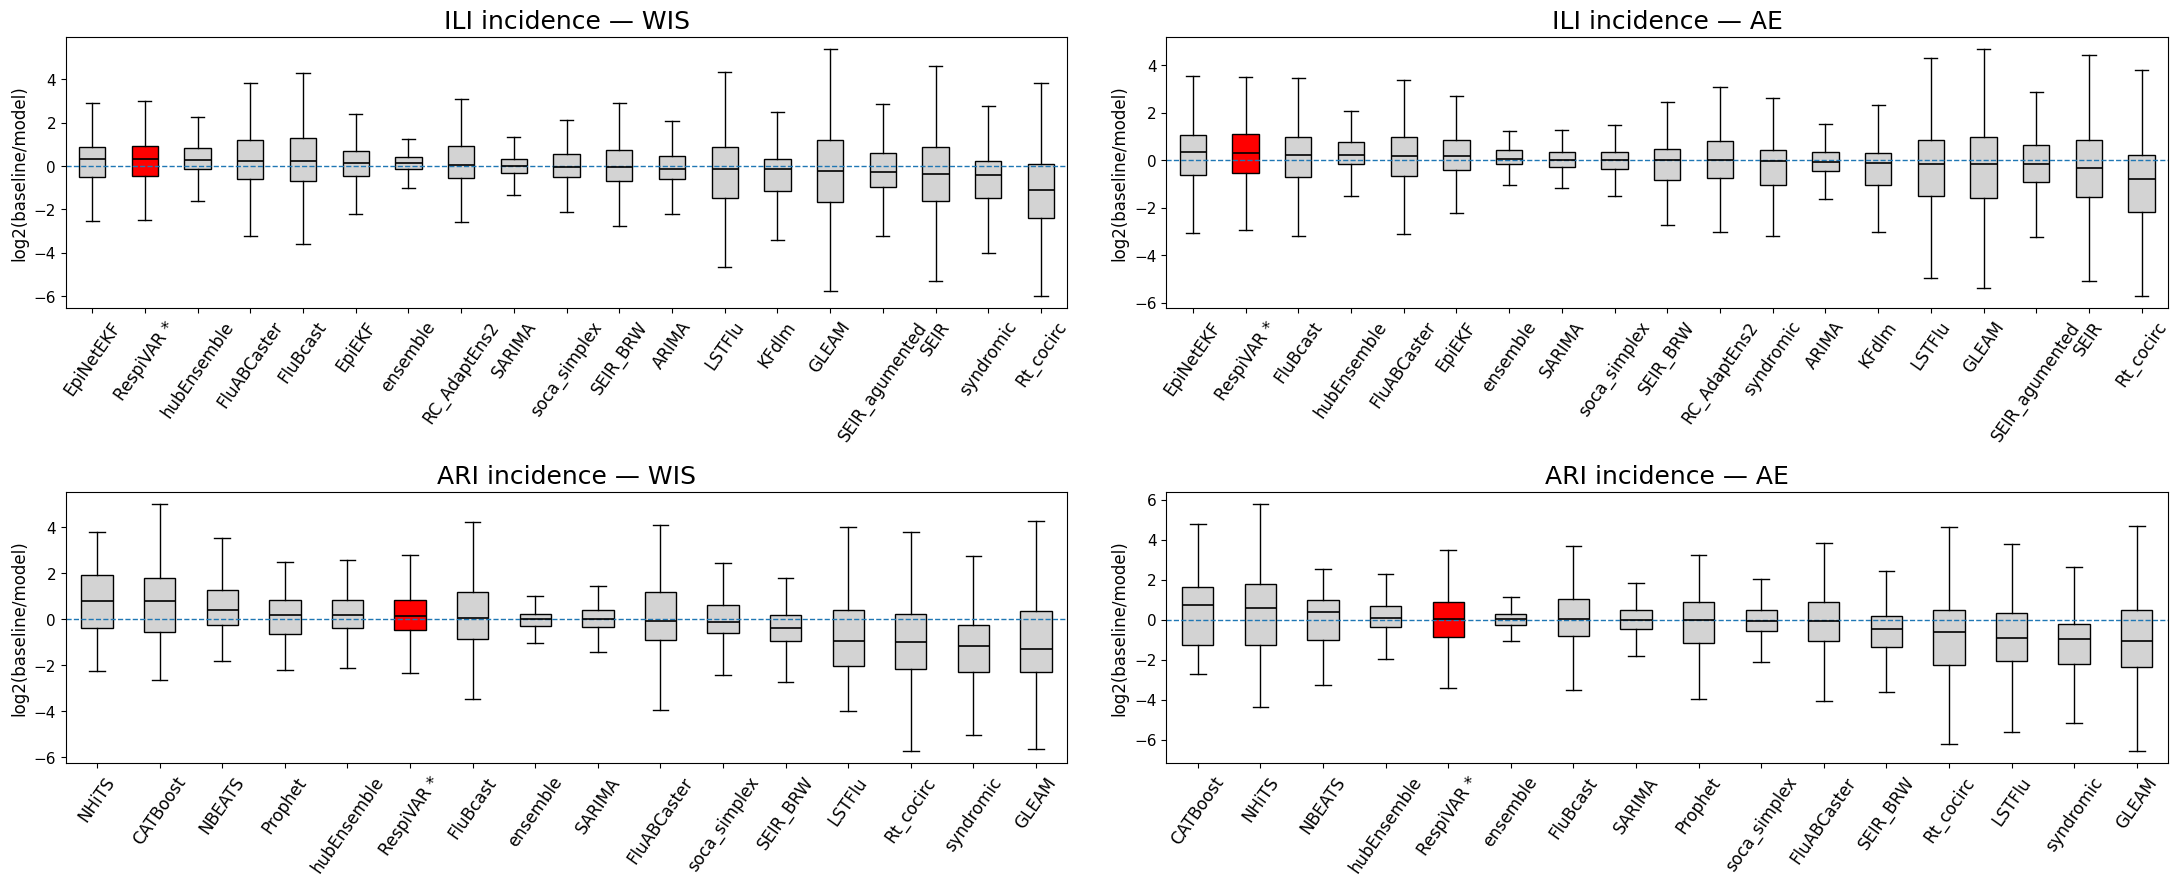

In [ ]:
# assuming filter_to_same_rounds(...) is already defined (from earlier)

def _prepare_for_plot(df, target, metric, drop_models=("quantileBaseline",), highlight="RespiVAR"):
    """Filter + order models by median value_relative (higher is better)."""
    d = df[(df["target"] == target) & (df["metric"] == metric)].copy()
    if drop_models:
        d = d[~d["model_id"].isin(drop_models)].copy()

    # order models by median relative performance (higher = better)
    order = (
        d.groupby("model_id")["value_relative"]
        .median()
        .sort_values(ascending=False)
        .index
        .tolist()
    )

    # build data arrays in that order
    data_arrays = [d.loc[d["model_id"] == m, "value_relative"].dropna().values for m in order]

    # add a star to highlight model label (no color needed)
    labels = [f"{m} *" if m == highlight else m for m in order]

    return d, order, data_arrays, labels

def plot_2x2_targets_metrics(
    data_all,
    targets=("ILI incidence", "ARI incidence"),
    metrics=("WIS", "AE"),
    ref_model_id="RespiVAR",
    ref_horizon=4,
    cutoff="2025-05-01",
    highlight="RespiVAR",
    drop_models=("quantileBaseline",),
    show_fliers=False,
):
    fig, axes = plt.subplots(
        nrows=len(targets),
        ncols=len(metrics),
        figsize=(22, 9),
        sharey=False
    )

    # make axes always 2D
    axes = np.atleast_2d(axes)

    infos = {}

    for i, tgt in enumerate(targets):
        # 1) restrict to target first
        df_tgt = data_all[data_all["target"] == tgt].copy()

        # 2) keep same rounds as reference model
        df_same_rounds, info = filter_to_same_rounds(
            df_tgt,
            ref_model_id=ref_model_id,
            ref_horizon=ref_horizon,
            cutoff=cutoff,
            verbose=False
        )

        # ---- print RespiVAR median relative scores (same rounds) ----
        for met in metrics:
            med = df_same_rounds.loc[
                (df_same_rounds["model_id"] == highlight) &
                (df_same_rounds["metric"] == met),
                "value_relative"
            ].median()
            print(f"{tgt} | {met} | {highlight} median value_relative: {med:.3f}")
        print("")  # blank line between targets

        infos[tgt] = info

        # quick optional sanity prints
        tmin = pd.to_datetime(df_same_rounds["target_end_date"]).min()
        tmax = pd.to_datetime(df_same_rounds["target_end_date"]).max()
        n_cty = df_same_rounds.loc[df_same_rounds["model_id"] == ref_model_id, "location"].nunique()
        print(f"[{tgt}] target_end_date range: {tmin.date()} → {tmax.date()} | n countries ({ref_model_id}): {n_cty}")

        for j, met in enumerate(metrics):
            ax = axes[i, j]

            d, order, data_arrays, labels = _prepare_for_plot(
                df_same_rounds, target=tgt, metric=met,
                drop_models=drop_models,
                highlight=highlight
            )

            # handle edge cases
            if len(order) == 0:
                ax.set_title(f"{tgt} — {met} (no data)")
                ax.axis("off")
                continue

            # --- boxplot with RespiVAR highlighted in red ---
            bp = ax.boxplot(
                data_arrays,
                tick_labels=labels,
                showfliers=show_fliers,
                patch_artist=True,
                medianprops=dict(color="black", linewidth=1.2),   # <- removes orange
                boxprops=dict(edgecolor="black", linewidth=1.0),
                whiskerprops=dict(color="black", linewidth=1.0),
                capprops=dict(color="black", linewidth=1.0),
            )

            # color boxes: RespiVAR red, others lightgray
            for k, (box, lab) in enumerate(zip(bp["boxes"], labels)):
                if lab.replace(" *", "") == highlight:   # highlight = "RespiVAR"
                    box.set_facecolor("red")
                else:
                    box.set_facecolor("lightgray")

            # optional: make medians/whiskers a bit visible
            for med in bp["medians"]: med.set_linewidth(1.2)

            ax.axhline(0, linestyle="--", linewidth=1)

            TITLE_FS = 18
            XTICK_FS = 12
            YTICK_FS = 11
            LABEL_FS = 12

            ax.set_title(f"{tgt} — {met}", fontsize=TITLE_FS)
            ax.tick_params(axis="x", labelrotation=55, labelsize=XTICK_FS)
            ax.tick_params(axis="y", labelsize=YTICK_FS)
            ax.set_ylabel("log2(baseline/model)", fontsize=LABEL_FS)


    plt.tight_layout(pad=1.2, w_pad=2.5, h_pad=1.5)
    plt.show()
    return fig, axes, infos


# ---- call it ----
# data_all should already be your long-form evaluation df with columns:
# ['target','metric','value_relative','model_id','origin_date','target_end_date','horizon','location', ...]
fig, axes, infos = plot_2x2_targets_metrics(
    data_all=data_all,
    targets=("ILI incidence", "ARI incidence"),
    metrics=("WIS", "AE"),
    ref_model_id="RespiVAR",
    ref_horizon=4,
    cutoff="2025-05-01",
    highlight="RespiVAR",
    drop_models=("quantileBaseline",),
    show_fliers=False,
)


In [ ]:
data_all

,origin_date,target,target_end_date,horizon,location,team_id,model_id,metric,value_absolute,baseline_value,value_relative,n_models,rank,rank_score
540,2024-10-23,ILI incidence,2024-10-20,1,AT,ECDC,SARIMA,WIS,328.856452,297.625826,-0.143958,10,3,0.882153
541,2024-10-23,ILI incidence,2024-10-20,1,AT,ItaLuxColab,EpiEKF,WIS,164.338422,297.625826,0.856830,10,1,1.000000
542,2024-10-23,ILI incidence,2024-10-20,1,AT,ItaLuxColab,EpiNetEKF,WIS,376.027352,297.625826,-0.337338,10,5,0.848364
543,2024-10-23,ILI incidence,2024-10-20,1,AT,MRC_GIDA,CATBoost,WIS,545.332289,297.625826,-0.873636,10,7,0.727089
544,2024-10-23,ILI incidence,2024-10-20,1,AT,MRC_GIDA,NBEATS,WIS,1560.374800,297.625826,-2.390321,10,10,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
128210,2025-12-10,ARI incidence,2025-12-07,1,SI,MRC_GIDA,TiDE,AE,1278.420048,677.300000,-0.916495,15,12,0.227853
128211,2025-12-10,ARI incidence,2025-12-07,1,SI,NotreDame,Rt_cocirc,AE,1139.300000,677.300000,-0.750281,15,11,0.329569
128212,2025-12-10,ARI incidence,2025-12-07,1,SI,respicast,hubEnsemble,AE,730.696799,677.300000,-0.109478,15,7,0.628315
128213,2025-12-10,ARI incidence,2025-12-07,1,SI,respicast,quantileBaseline,AE,677.300000,677.300000,0.000000,15,6,0.667356


## Part 2

In [ ]:
type = 'ARI incidence'
dff = data_all[data_all['target']==type]

In [ ]:
df_same_rounds, info = filter_to_same_rounds(
    dff,
    ref_model_id="RespiVAR",
    ref_horizon=4,
    cutoff="2025-05-01",
    verbose=True
)

Max RespiVAR h=4 target_end_date < cutoff: 2025-04-27
origin_date(s) that generated it: [datetime.date(2025, 4, 9)]
Using last_origin = 2025-04-09
N origin dates kept: 25
From 2024-10-23 to 2025-04-09
Filtered rows: 30496
Unique origin dates: 25
Models present: 17


In [ ]:
df = df_same_rounds[df_same_rounds['target']==type]

In [ ]:
tmin = pd.to_datetime(df_same_rounds["target_end_date"]).min()
tmax = pd.to_datetime(df_same_rounds["target_end_date"]).max()
print("from", tmin, "to", tmax)

from 2024-10-20 00:00:00 to 2025-04-27 00:00:00


/tmp/ipykernel_1841/3801204202.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


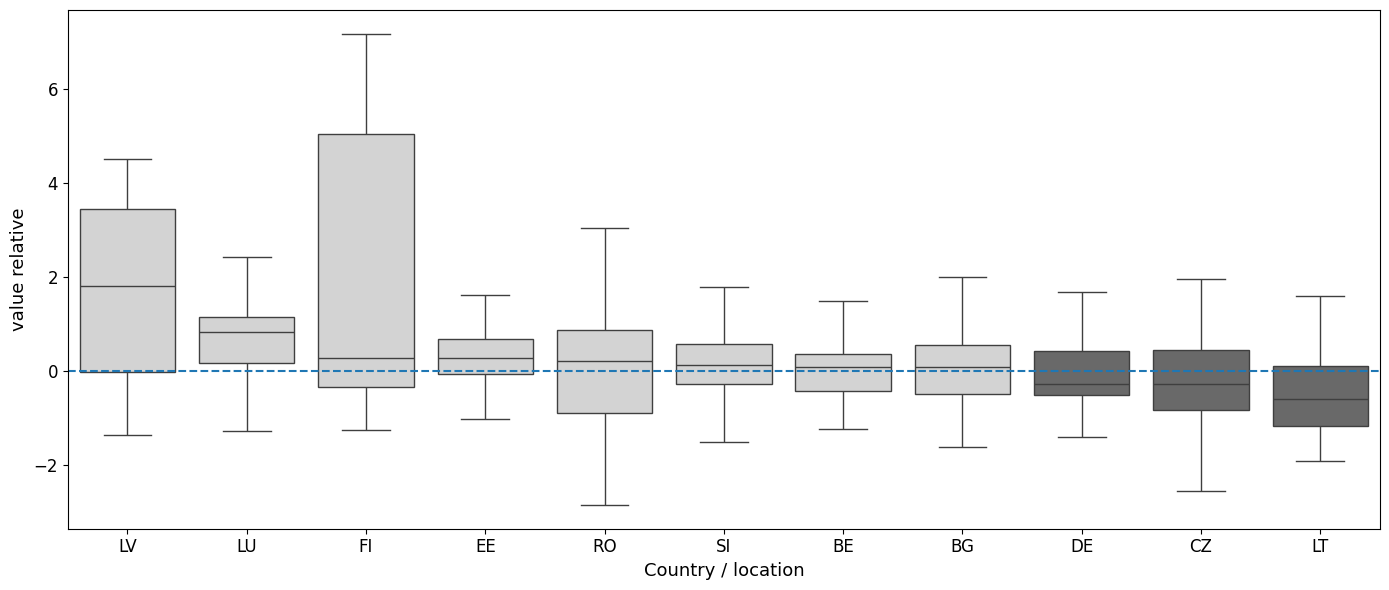

In [ ]:
metric = "WIS"
model_id = "RespiVAR"

d = df[(df["model_id"] == model_id) & (df["metric"] == metric)].copy()

# order by median (ascending)
med = d.groupby("location")["value_relative"].median().sort_values(ascending=False)
order_loc = med.index.tolist()

palette = {loc: ("lightgray" if med.loc[loc] > 0 else "dimgray") for loc in order_loc}

plt.figure(figsize=(max(14, len(order_loc)*0.35), 6))
sns.boxplot(
    data=d,
    x="location",
    y="value_relative",
    order=order_loc,
    palette=palette,
    showfliers=False
)
plt.axhline(0, linestyle="--")  # baseline line
plt.xticks(rotation=0, fontsize=12)
plt.yticks(fontsize=12)
plt.xlabel("Country / location", fontsize=13)
plt.ylabel("value relative", fontsize=13)
# plt.title(f"{metric} per country, all horizons")
plt.tight_layout()
plt.show()


/tmp/ipykernel_1841/2661683125.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


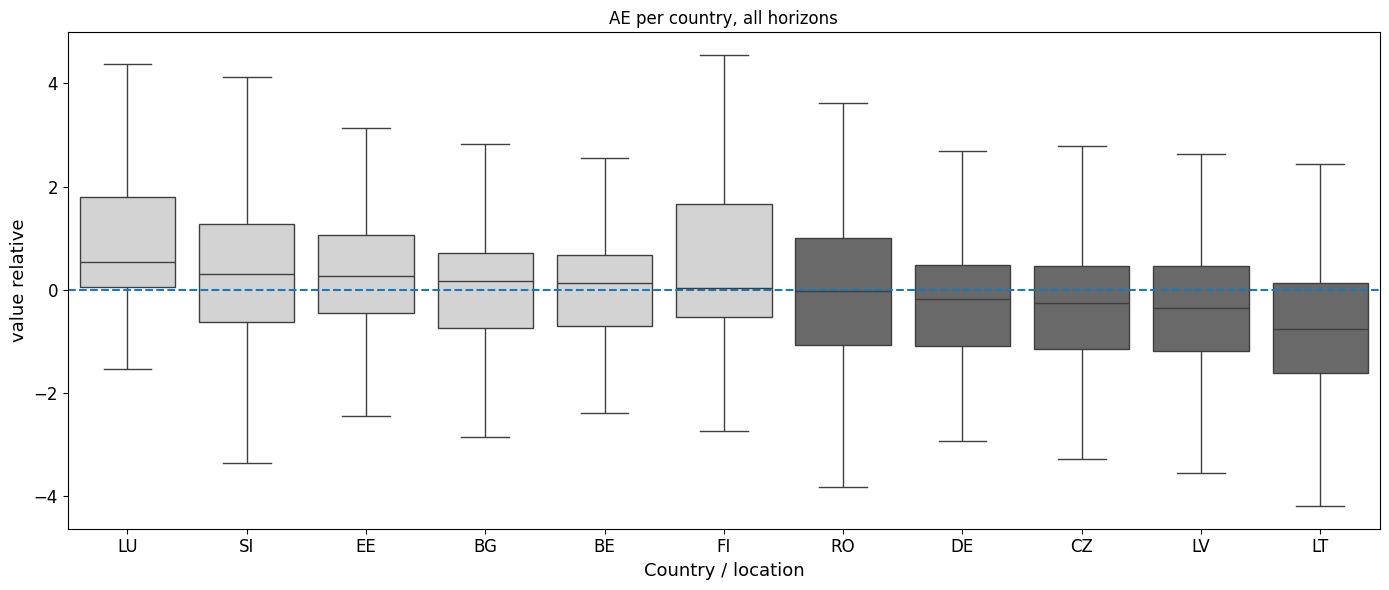

In [ ]:
metric = "AE"
model_id = "RespiVAR"

d = df[(df["model_id"] == model_id) & (df["metric"] == metric)].copy()

# order by median (ascending)
med = d.groupby("location")["value_relative"].median().sort_values(ascending=False)
order_loc = med.index.tolist()

palette = {loc: ("lightgray" if med.loc[loc] > 0 else "dimgray") for loc in order_loc}

plt.figure(figsize=(max(14, len(order_loc)*0.35), 6))
sns.boxplot(
    data=d,
    x="location",
    y="value_relative",
    order=order_loc,
    palette=palette,
    showfliers=False
)

plt.axhline(0, linestyle="--")  # baseline line
plt.xticks(rotation=0, fontsize=12)
plt.yticks(fontsize=12)
plt.xlabel("Country / location", fontsize=13)
plt.ylabel("value relative", fontsize=13)
plt.title(f"{metric} per country, all horizons")
plt.tight_layout()
plt.show()


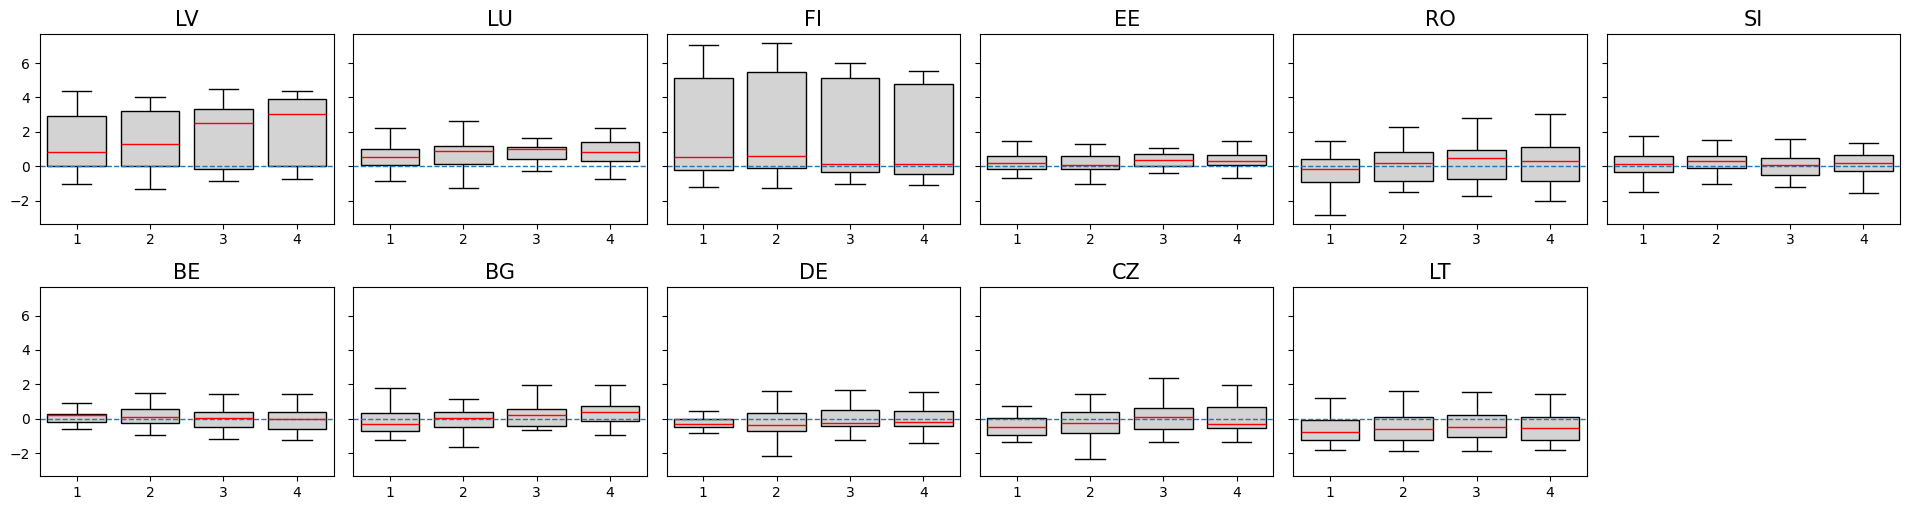

In [ ]:
metric = "WIS"      # or "AE"
model_id = "RespiVAR" # your model

d = df[(df["model_id"] == model_id) & (df["metric"] == metric)].copy()

# sort countries by median (descending)
med = d.groupby("location")["value_relative"].median().sort_values(ascending=False)
countries = med.index.tolist()

# horizons order (if numeric it will sort nicely; otherwise keep as strings)
h_order = sorted(d["horizon"].dropna().unique())

# layout
n = len(countries)
ncols = 6
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols*3.2, nrows*2.6), sharey=True)
axes = axes.flatten()

for i, loc in enumerate(countries):
    ax = axes[i]
    dd = d[d["location"] == loc].copy()

    # 4 boxplots: one per horizon
    sns.boxplot(
        data=dd,
        x="horizon",
        y="value_relative",
        order=h_order,
        showfliers=False,
        boxprops=dict(facecolor="lightgray", edgecolor="black"),
        medianprops=dict(color="red", linewidth=1),
        whiskerprops=dict(color="black"),
        capprops=dict(color="black"),
        ax=ax
    )
    ax.axhline(0, linestyle="--", linewidth=1)
    ax.set_title(loc, fontsize=15)
    ax.set_xlabel("")
    ax.set_ylabel("")

    plt.xticks(rotation=0, fontsize=14)
    plt.yticks(fontsize=14)
    ax.tick_params(axis="x", rotation=0)

# turn off unused axes
for j in range(i + 1, len(axes)):
    axes[j].axis("off")

#fig.suptitle(f"{metric} relative to baseline — {model_id} (boxplots by horizon, one panel per country)", y=1.02)
plt.tight_layout()
plt.show()


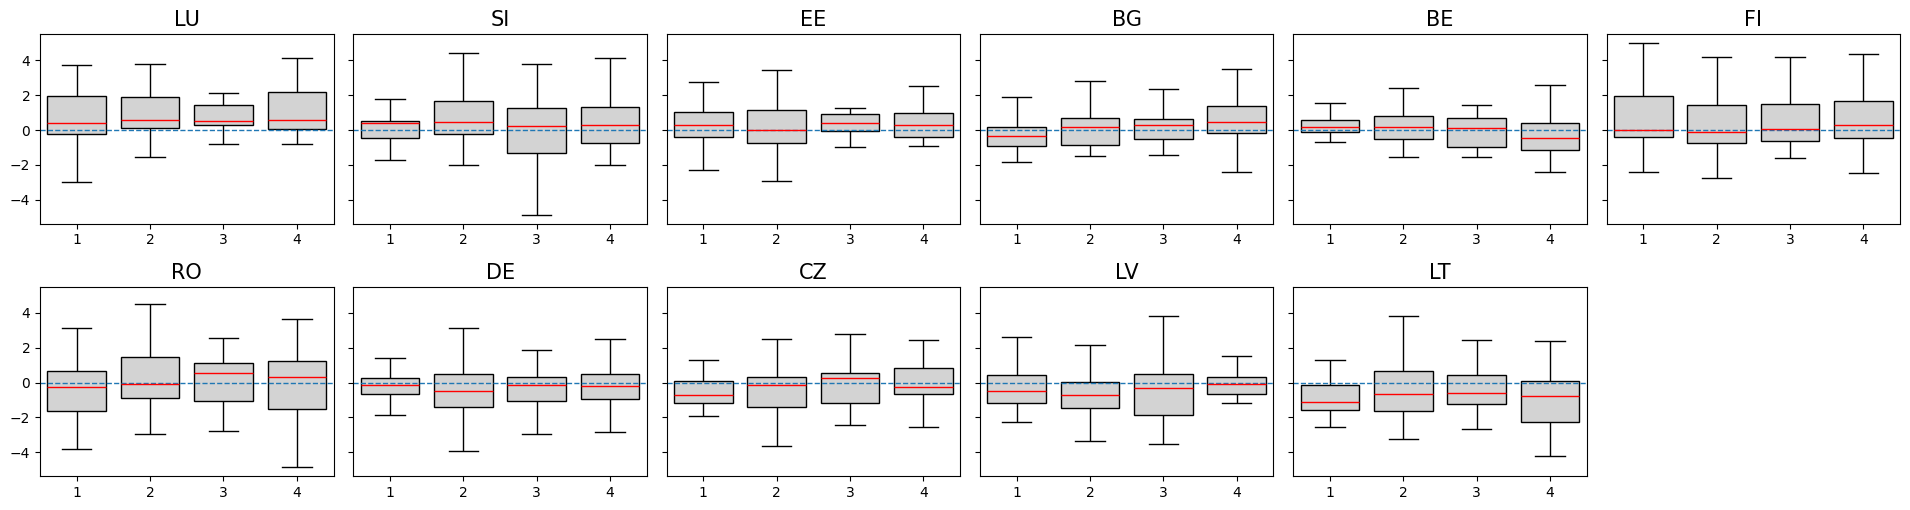

In [ ]:
metric = "AE"      # or "AE"
model_id = "RespiVAR" # your model

d = df[(df["model_id"] == model_id) & (df["metric"] == metric)].copy()

# sort countries by median (descending)
med = d.groupby("location")["value_relative"].median().sort_values(ascending=False)
countries = med.index.tolist()

# horizons order (if numeric it will sort nicely; otherwise keep as strings)
h_order = sorted(d["horizon"].dropna().unique())

# layout
n = len(countries)
ncols = 6
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols*3.2, nrows*2.6), sharey=True)
axes = axes.flatten()

for i, loc in enumerate(countries):
    ax = axes[i]
    dd = d[d["location"] == loc].copy()

    # 4 boxplots: one per horizon
    sns.boxplot(
        data=dd,
        x="horizon",
        y="value_relative",
        order=h_order,
        showfliers=False,
        boxprops=dict(facecolor="lightgray", edgecolor="black"),
        medianprops=dict(color="red", linewidth=1),
        whiskerprops=dict(color="black"),
        capprops=dict(color="black"),
        ax=ax
    )
    ax.axhline(0, linestyle="--", linewidth=1)
    ax.set_title(loc, fontsize=15)
    ax.set_xlabel("")
    ax.set_ylabel("")

    plt.xticks(rotation=0, fontsize=14)
    plt.yticks(fontsize=14)
    ax.tick_params(axis="x", rotation=0)

# turn off unused axes
for j in range(i + 1, len(axes)):
    axes[j].axis("off")

# fig.suptitle(f"{metric} relative to baseline — {model_id} (boxplots by horizon, one panel per country)", y=1.02)
plt.tight_layout()
plt.show()
